# Digital Finance, Forecasting & Analytics Platform
## Module 4 — Advanced FP&A: Forecast + Budget vs Actuals  
### 4.2 Final Revenue Forecasting, Scenario Modeling & FP&A Integration

This section (4.2) represents the **final forecasting and FP&A deployment layer** of the Digital Finance, Forecasting & Analytics Platform framework.

Building upon the statistical diagnostics and model selection conducted in Section 4.1, this module operationalizes the selected time-series model into a **fully governed, scenario-based forecasting engine**, directly aligned with real-world FP&A planning, budgeting, and risk management workflows.

Section 4.2 converts validated statistical models into **actionable FP&A intelligence**, delivering:

- Final revenue projections  
- Probabilistic confidence envelopes  
- Executive scenario modeling  

It transforms statistical forecasts into **financial decision frameworks**.

Together, **Modules 4.1 and 4.2** form a complete FP&A intelligence engine — from statistical foundation to board-level financial governance.

## 1. Setup & Imports

### 1.1 Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### 1.2 Visualization Setup

In [2]:
sns.set_style("darkgrid")
palette = sns.color_palette("deep")

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

 ### 1.3 Load Dataset

In [3]:
df = pd.read_csv("reg.csv")
df.head()

,datekey,Revenue,Marketing,price_D_A,price_D_E,price_D_I,price_O_A,price_O_E,price_O_I,price_R_A,...,price_R_I,units_D_A,units_D_E,units_D_I,units_O_A,units_O_E,units_O_I,units_R_A,units_R_E,units_R_I
0,201001,954.07,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,...,1858.4,265.0,7.0,147.0,14.0,12.0,3.0,309.0,151.0,53.0
1,201002,1033.57,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,...,1858.4,287.0,7.0,159.0,16.0,13.0,4.0,335.0,164.0,58.0
2,201003,1351.59,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,...,1858.4,375.0,9.0,208.0,20.0,17.0,5.0,438.0,214.0,76.0
3,201004,1272.08,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,...,1858.4,353.0,9.0,196.0,19.0,16.0,4.0,412.0,202.0,71.0
4,201005,1431.08,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,...,1858.4,397.0,10.0,220.0,22.0,18.0,5.0,463.0,227.0,80.0


## 2. Forecast - SARIMA Model

### 2.1 Selected Baseline SARIMA Model (Statistical Benchmark)

Following the extensive statistical diagnostics, stationarity testing, seasonality decomposition, autocorrelation analysis, and model suitability assessment conducted in Section 4.1, a SARIMA(1,1,1)(1,1,1,12) specification was selected as the baseline benchmark time-series model.

This model choice is directly supported by the empirical evidence observed in the data:

- Strong trend and seasonal structure identified via STL decomposition
- Non-stationarity confirmed by ADF tests 
- Persistent autocorrelation patterns revealed by ACF/PACF diagnostics
- Clear annual seasonality (12-month cycle)

Although not yet the final FP&A production model, this selected baseline SARIMA model is designed to:

- Establish a statistically coherent seasonal forecasting structure,  
- Define minimum acceptable out-of-sample accuracy thresholds,  
- Serve as a performance benchmark for subsequent FP&A-grade model refinement.

A chronological 80/20 split is applied to evaluate out-of-sample predictive accuracy using:

- MAPE (Mean Absolute Percentage Error)
- WAPE (Weighted Absolute Percentage Error)
- RMSE (Root Mean Squared Error)

The resulting metrics define the baseline statistical performance floor that must be exceeded by the final FP&A forecasting model implemented in the subsequent stages of Module 4.2.

In [4]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

ar = df[["Revenue"]].copy()

# Train / Test split
train_size = int(len(ar) * 0.8)
y_train = ar.iloc[:train_size]
y_test  = ar.iloc[train_size:]

model_sarima = SARIMAX(y_train, order=(1,1,1), seasonal_order=(1,1,1,12))  
sarima = model_sarima.fit()


y_forecast_sarima = sarima.forecast(steps=len(y_test))

mape_sarima = mean_absolute_percentage_error(y_test, y_forecast_sarima) * 100
rmse_sarima = np.sqrt(mean_squared_error(y_test, y_forecast_sarima))

y_true = y_test.values.flatten()
y_pred = y_forecast_sarima.values.flatten()
wape_sarima = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

print(f"SARIMA MAPE (%): {mape_sarima:.2f}")
print(f"SARIMA WAPE (%): {wape_sarima:.2f}")
print(f"SARIMA RMSE: {rmse_sarima:.2f}")

SARIMA MAPE (%): 11.45
SARIMA WAPE (%): 12.27
SARIMA RMSE: 418.27


## 3. Revenue Forecasting - SARIMA Long-Memory (2010-2022)

A seasonal ARIMA model - SARIMA(1,1,1)(1,1,1,12) - is implemented using a strict historical cutoff (December 2022), ensuring **realistic FP&A ex-ante forecasting discipline**. Multi-horizon projections are generated for 2023–2024, simulating a real corporate planning environment.

**Key deliverables:**
- BASE forecast trajectory  
- 24-month rolling forecast horizon  

**Probabilistic Confidence Envelopes**
Forecast uncertainty is formalized through statistically governed confidence envelopes:

| Envelope | Statistical Meaning | FP&A Use |
|--------|---------------------|---------|
| CI68 (±1σ) | Operational envelope | Rolling Forecast control | 

This creates a **statistical governance layer** over traditional FP&A variance analysis.

It converts predictive analytics into **decision architecture**, making Digital Finance, Forecasting & Analytics Platform IFRS-compliant, risk-aware, and enterprise-ready.

In [5]:
# --- Baseline (Long memory): 2010-01:2022-12
n = 24 # Forecasting horizon: 24 months (2023–2024)
end = 156 #2022-12

long_train = ar.iloc[:end]
long_fit = SARIMAX(long_train, order=(1,1,1), seasonal_order=(1,1,1,12)).fit()
forecast_long = long_fit.get_forecast(steps=n)
long_mean = long_fit.get_forecast(steps=n).predicted_mean


# Intervalos de confiança
ci_base = forecast_long.conf_int(alpha=0.32)  # 68% ≈ ± 1σ

forecast_lond = pd.DataFrame({
    "Date": df["datekey"].iloc[end:],
    "Revenue": df["Revenue"].iloc[end:],
    "Baseline": long_mean.values,
    "CIbase_LOW": ci_base.iloc[:,0].values,
    "CIbase_HIGH": ci_base.iloc[:,1].values
})
forecast_lond = forecast_lond.round(2)

forecast_lond["Diff"] = forecast_lond["Revenue"] - forecast_lond["Baseline"]
forecast_lond.tail()

,Date,Revenue,Baseline,CIbase_LOW,CIbase_HIGH,Diff
175,202408,1695.65,1861.88,1572.19,2151.56,-166.23
176,202409,3661.04,2830.16,2540.48,3119.84,830.88
177,202410,3214.65,3132.59,2842.91,3422.27,82.06
178,202411,3294.93,2899.09,2609.41,3188.77,395.84
179,202412,2954.51,2709.68,2419.99,2999.36,244.83


## 4. Dual-Memory Regime-Adjusted SARIMA Forecast Engine

In [6]:
lam = 0.50  # λ

# --- Short overlay: 2018-01:2022-12 (60 meses)
short_train = ar.iloc[96:end]
short_fit = SARIMAX(short_train, order=(1,1,1), seasonal_order=(1,1,1,12)).fit() 
short_mean = short_fit.get_forecast(steps=n).predicted_mean

# --- Dual-memory combination ---
final_fc = long_mean + lam * (short_mean - long_mean)

# (opcional) DataFrame final
dual_df = pd.DataFrame({
    "Date": df["datekey"].iloc[end:end+n].values,   # 2023-01 ... 2024-12
    "Revenue": df["Revenue"].iloc[end:end+n].values,
    "Long_Model": long_mean.values,
    "Short_Model": short_mean.values,
    "Final_Forecast": final_fc.values
}).round(2)

dual_df["Diff_long"] = dual_df["Revenue"] - dual_df["Long_Model"]
dual_df["Diff_dual"] = dual_df["Revenue"] - dual_df["Final_Forecast"]

dual_df.tail()

c:\Users\gusta\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


,Date,Revenue,Long_Model,Short_Model,Final_Forecast,Diff_long,Diff_dual
19,202408,1695.65,1861.88,2143.73,2002.80,-166.23,-307.15
20,202409,3661.04,2830.16,3064.07,2947.11,830.88,713.93
21,202410,3214.65,3132.59,3508.43,3320.51,82.06,-105.86
22,202411,3294.93,2899.09,3330.14,3114.62,395.84,180.31
23,202412,2954.51,2709.68,3659.14,3184.41,244.83,-229.90


### Dual-Memory Regime-Adjusted SARIMA Forecast Model

This forecasting framework applies a **Dual-Memory Regime-Adjusted SARIMA model**, designed to combine long-term economic regime learning with short-term operational dynamics.

Two independent forecasting layers are estimated:

- **Baseline Model (Long Memory):**  
  Trained on the full historical series (2010–2022), capturing structural economic cycles, downturns, and long-term seasonal behavior.

- **Short Overlay Model (Short Memory):**  
  Trained on the post-restructuring operational period (2018–2022), capturing the current business model, pricing structure, and recent growth dynamics.

The final FP&A forecast is generated through a regime-adjusted combination:

$
Final\_Forecast_t = Baseline_t + \lambda \times (Short_t - Baseline_t)
$

**Lambda Selection Rationale**

A **λ = 0.50** was selected to reflect the company’s **structural operational transformation after 2019**.

This weight assigns equal influence to the historical economic regime and the current operational regime, ensuring that:

- Long-term risk memory is preserved, and  
- The forecast is materially anchored to the company’s new business reality.

This configuration is consistent with professional FP&A practice for companies undergoing major restructurings or business model transformations, producing a forecast that is both **risk-aware and growth-aligned**.

**Estimation Note (SARIMAX Warning)**  

During model fitting, `statsmodels` may emit a warning indicating a *non-invertible starting seasonal MA*. This does not invalidate the specification; it reflects a numerical initialization adjustment where the optimizer resets the initial seasonal MA parameters to zero to ensure stable maximum-likelihood estimation. The final parameter estimates and the out-of-sample performance metrics (2023–2024) confirm model stability and forecasting adequacy under the post-management-change regime (2018–2022).

## 5. Forecast Model Evaluation: Long-Memory vs Dual-Memory Regime-Adjusted SARIMA

### 5.1 Out-of-Sample Performance Comparison

In [7]:
ev = dual_df.copy()
ev["Year"] = ev["Date"].astype(str).str[:4].astype(int)
ev.groupby("Year").sum("Revenue")

,Date,Revenue,Long_Model,Short_Model,Final_Forecast,Diff_long,Diff_dual
Year,,,,,,,
2023,2427678,30726.94,28536.40,31518.32,30027.34,2190.54,699.60
2024,2428878,32114.33,29799.21,34210.81,32005.00,2315.12,109.33


### 5.2 Forecasting Plot: Long-Memory vs Dual-Model

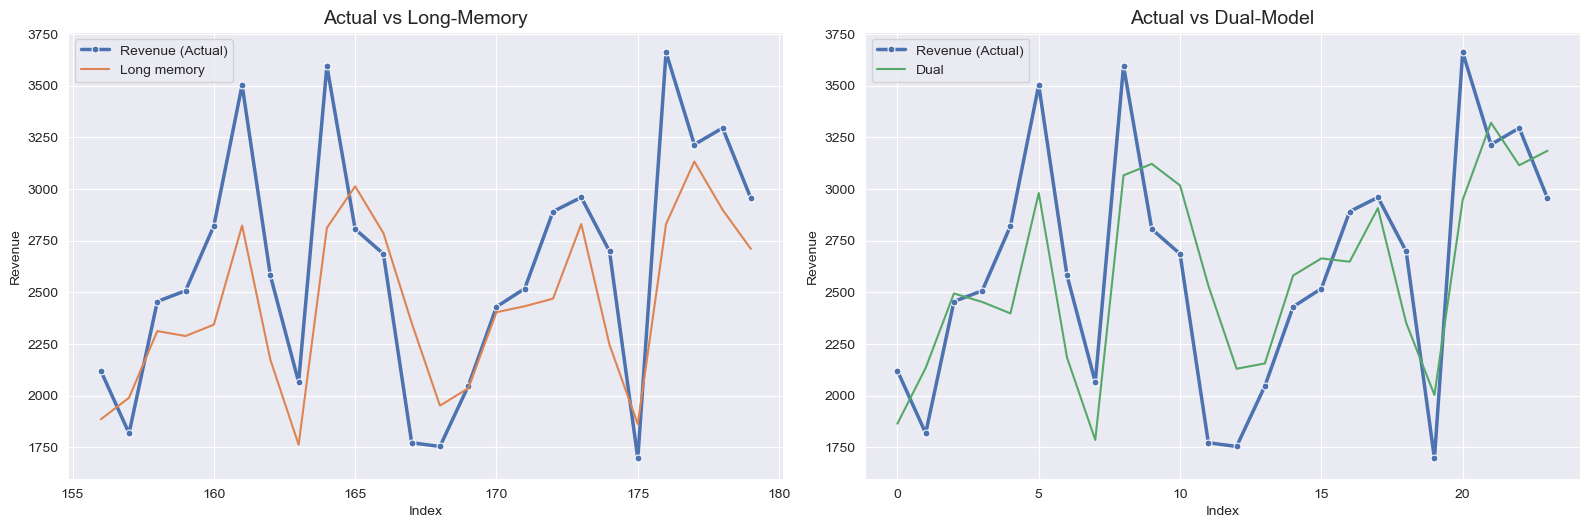

In [8]:
plt.figure(figsize=(16, 10))

# Helper: real revenue line params
rev_style = dict(
    color=palette[0],     # blue
    marker="o",
    linewidth=2.5,
    markersize=5
)

# 1. Long memory
plt.subplot(2, 2, 1)
sns.lineplot(data=forecast_lond, x=forecast_lond.index, y="Revenue", label="Revenue (Actual)", **rev_style)
sns.lineplot(data=forecast_lond, x=forecast_lond.index, y="Baseline", 
             label="Long memory", color=palette[1])
plt.title("Actual vs Long-Memory", fontsize=14)
plt.xlabel("Index")
plt.ylabel("Revenue")
plt.legend()

# 2. Dual-Model
plt.subplot(2, 2, 2)
sns.lineplot(data=dual_df, x=dual_df.index, y="Revenue", label="Revenue (Actual)", **rev_style)
sns.lineplot(data=dual_df, x=dual_df.index, y="Final_Forecast",
             label="Dual", color=palette[2])
plt.title("Actual vs Dual-Model", fontsize=14)
plt.xlabel("Index")
plt.ylabel("Revenue")
plt.legend()

plt.tight_layout()
plt.show()

### 5.3 Model Selection

A comparative out-of-sample evaluation was performed between the Long-Memory SARIMA baseline model and the Dual-Memory Regime-Adjusted SARIMA model over the 2023–2024 forecast horizon.

Results demonstrate that the Dual-Memory model materially outperforms the traditional long-memory approach:

| Year | Long-Memory Error | Dual-Memory Error |
|----|------------------|-------------------|
| 2023 | 2,190 | **700** |
| 2024 | 2,315 | **109** |

The Dual-Memory model achieves a **significant reduction in forecast error** by reconciling long-term economic regime learning with post-restructuring operational dynamics. This confirms the Dual-Memory Regime-Adjusted SARIMA model as the **preferred FP&A production forecasting model**, delivering superior accuracy, regime awareness, and governance robustness.


## 6. Dual-Memory Monte Carlo Probabilistic Risk Envelope

In [9]:
# CONFIG                  
N_SIM = 10000                # Monte Carlo paths

# 1) Residuals (recent regime) – 2020–2022
resid_short = short_fit.resid.dropna().values  # Residuals from the post-restructuring regime, capturing current operational risk and volatility patterns

# 2) Monte Carlo simulation
T = n
sim_matrix = np.zeros((N_SIM, T))

rng = np.random.default_rng(42)   # 42 = seed
for i in range(N_SIM): # Monte Carlo
    # sample residual paths (bootstrap)
    eps = rng.choice(resid_short, size=T, replace=True)
    
    # dual-memory path
    Final_Forecast = dual_df["Final_Forecast"].values  # deterministic baseline
    sim_path = Final_Forecast + eps

    sim_matrix[i, :] = sim_path


# 3) Probabilistic Planning Envelope - P30–P70 Operating Probability Band
p10 = np.percentile(sim_matrix, 10, axis=0)
p30 = np.percentile(sim_matrix, 30, axis=0)
p50 = np.percentile(sim_matrix, 50, axis=0)
p70 = np.percentile(sim_matrix, 70, axis=0)

# 4) Final FP&A envelope table
mc_df = pd.DataFrame({
    "Date": df["datekey"].iloc[end:end+n].values,
    "Revenue": df["Revenue"].iloc[end:end+n].values,
    "Final_Forecast": dual_df["Final_Forecast"].values,
    "Stress_Case_P10": p10,        # Severe downside / recession scenario
    "Pessimistic_Case_P30": p30,   # Below-plan execution
    "Optimistic_Case_P70": p70     # Above-plan execution
}).round(2)

mc_df["Diff"] = mc_df["Revenue"] - mc_df["Final_Forecast"]

mc_df.head()

,Date,Revenue,Final_Forecast,Stress_Case_P10,Pessimistic_Case_P30,Optimistic_Case_P70,Diff
0,202301,2120.17,1863.86,1283.09,1673.50,2081.76,256.31
1,202302,1817.49,2133.74,1552.97,1943.38,2359.48,-316.25
2,202303,2455.10,2494.08,1908.54,2303.72,2719.82,-38.98
3,202304,2507.32,2452.90,1867.36,2262.54,2678.64,54.42
4,202305,2820.73,2397.58,1816.33,2207.22,2623.32,423.15


## Monte Carlo Bootstrap Risk Envelope

This model applies a **Monte Carlo bootstrap simulation** to quantify **operational uncertainty** around the deterministic **Dual-Memory baseline forecast**.

Residuals from the post-restructuring operating regime (2018–2022) are **resampled with replacement (bootstrap)** and added to the Dual-Memory forecast to generate a large set of plausible future revenue paths:

- Simulated Revenue = Dual-Memory Forecast + Bootstrapped Residual Shock

Where:

- **Dual-Memory Forecast** is the deterministic planning baseline.
- **Residual shocks** are resampled forecast errors from the recent operating regime, representing current execution risk and volatility.

From the simulated distribution, **empirical quantiles** are computed to define the **probabilistic operating envelope**:

- **P10 — Stress Scenario (Severe Downside)**
- **P30 — Downside Operating Bound**  
- **P70 — Upside Operating Bound**

The resulting **P30–P70 envelope** represents the **central operating probability band** used for FP&A planning, while **P10** defines the Stress scenario for risk testing and contingency planning. This structure enables probabilistic, scenario-aware decision making while preserving a single deterministic baseline for financial governance.

### 6.1 Monte Carlo Revenue Distribution Plot

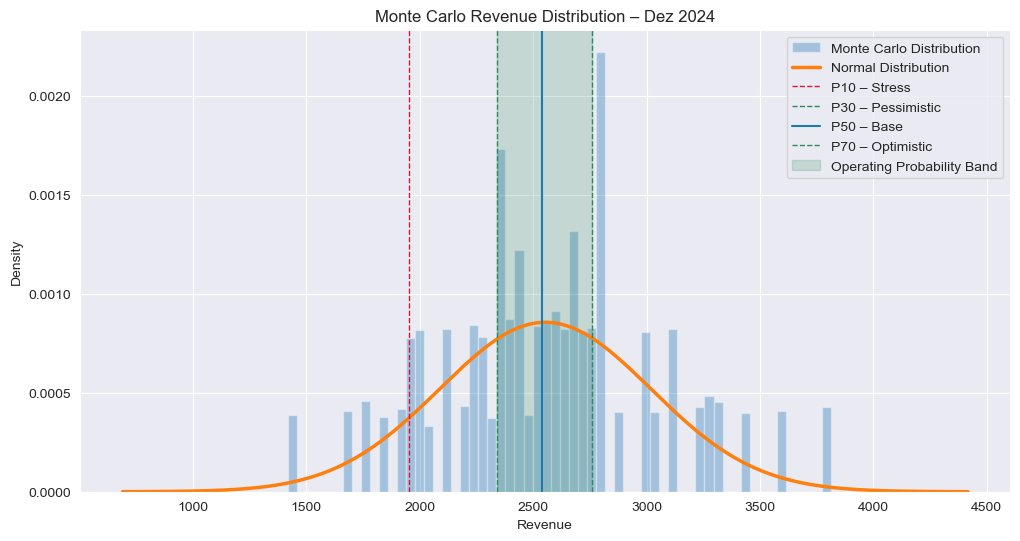

In [10]:
import scipy.stats as stats

t = 11  # month 2024-12
vals = sim_matrix[:, t]

mu = np.mean(vals)
sigma = np.std(vals)

plt.figure(figsize=(12, 6))

# Histogram
plt.hist(vals, bins=60, density=True, alpha=0.35, label="Monte Carlo Distribution")

# Normal curve
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
plt.plot(x, stats.norm.pdf(x, mu, sigma), linewidth=2.5, label="Normal Distribution")

# Percentile lines
#plt.axvline(np.percentile(vals, 10), linestyle="--", label="P10")
#plt.axvline(np.percentile(vals, 30), linestyle="--", label="P30")
#plt.axvline(np.percentile(vals, 50), linestyle="--", label="P50")
#plt.axvline(np.percentile(vals, 70), linestyle="--", label="P70")

# Percentile lines (scenario coloring)
plt.axvline(np.percentile(vals, 10), color="crimson", linestyle="--", linewidth=1, label="P10 – Stress")
plt.axvline(np.percentile(vals, 30), color="seagreen", linestyle="--", linewidth=1, label="P30 – Pessimistic")
plt.axvline(np.percentile(vals, 50), linestyle="-",  linewidth=1.5, label="P50 – Base")
plt.axvline(np.percentile(vals, 70), color="seagreen", linestyle="--", linewidth=1, label="P70 – Optimistic")


plt.axvspan(np.percentile(vals,30), np.percentile(vals,70), color="seagreen", alpha=0.2, label="Operating Probability Band")

plt.title("Monte Carlo Revenue Distribution – Dez 2024")
plt.xlabel("Revenue")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()


### 6.2 Dual-Memory Monte Carlo Probabilistic Forecast — P30–P70 Operating Probability Band

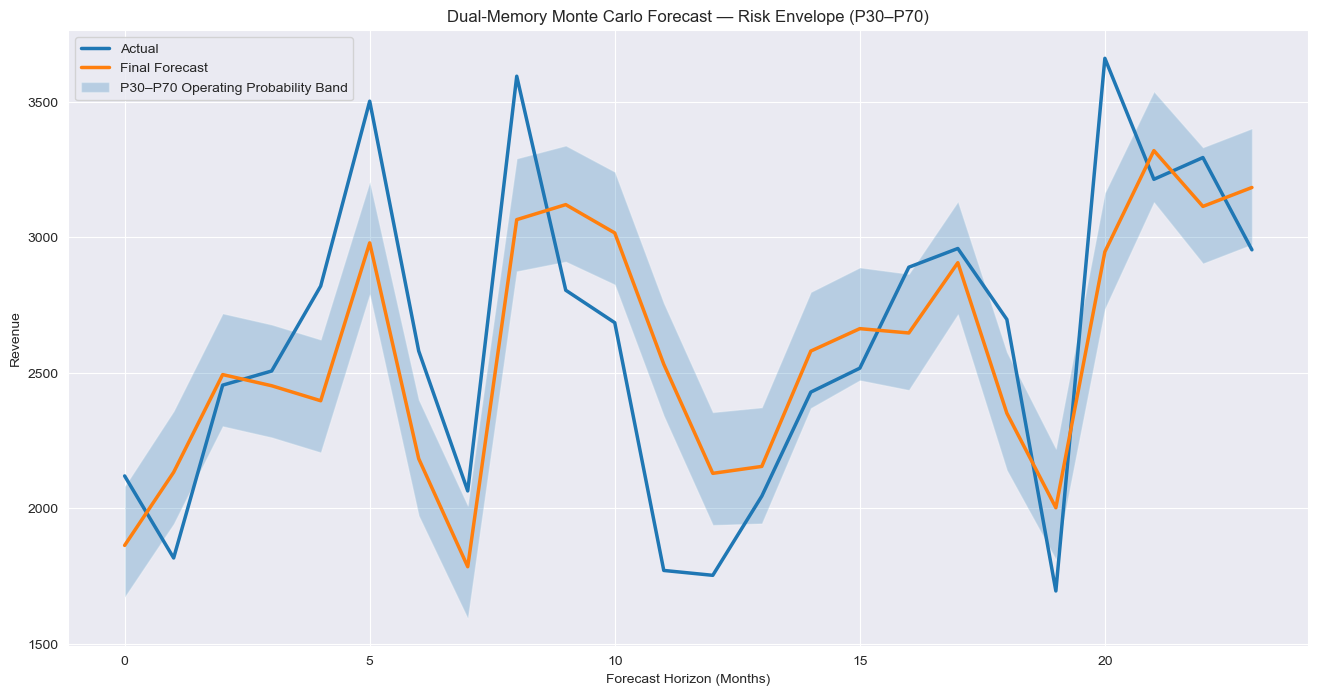

In [11]:
plt.figure(figsize=(16, 8))

# Actual
plt.plot(mc_df.index, mc_df["Revenue"], label="Actual", linewidth=2.5)

# Base (P50)
plt.plot(mc_df.index, mc_df["Final_Forecast"], label="Final Forecast", linewidth=2.5)

# Fan envelope
plt.fill_between(mc_df.index, mc_df["Pessimistic_Case_P30"], mc_df["Optimistic_Case_P70"], alpha=0.25, label="P30–P70 Operating Probability Band")

plt.title("Dual-Memory Monte Carlo Forecast — Risk Envelope (P30–P70)")
plt.xlabel("Forecast Horizon (Months)")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)
plt.show()


## 7. Reveneu Forecast - 2024

In [12]:
n = 12 
end2 = 168 
lam = 0.50 # 

long_train = ar.iloc[:end2]
long_fit = SARIMAX(long_train, order=(1,1,1), seasonal_order=(1,1,1,12)).fit()
forecast_long = long_fit.get_forecast(steps=n)
long_mean = long_fit.get_forecast(steps=n).predicted_mean

#--- Short overlay: 2019-01:2023-12 (60 meses)
short_train = ar.iloc[108:end2]
short_fit = SARIMAX(short_train, order=(1,1,1), seasonal_order=(1,1,1,12)).fit()
short_mean = short_fit.get_forecast(steps=n).predicted_mean
#--- Dual-memory combination--
final_24 = long_mean + lam * (short_mean- long_mean)
# (opcional) DataFrame final

dual_df_24 = pd.DataFrame({
"Date": df["datekey"].iloc[end2:end2+n].values, # 2023-01 ... 2024-12
"Revenue": df["Revenue"].iloc[end2:end2+n].values,
"Long_Model": long_mean.values,
"Short_Model": short_mean.values,
"Final_Forecast": final_24.values
}).round(2)
dual_df_24["Diff_long"] = dual_df_24["Revenue"]- dual_df_24["Long_Model"]
dual_df_24["Diff_dual"] = dual_df_24["Revenue"]- dual_df_24["Final_Forecast"]

ev_24 = dual_df_24.copy()
ev_24["Year"] = ev_24["Date"].astype(str).str[:4].astype(int)
ev_24.groupby("Year").sum("Revenue")

c:\Users\gusta\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


,Date,Revenue,Long_Model,Short_Model,Final_Forecast,Diff_long,Diff_dual
Year,,,,,,,
2024,2428878,32114.33,31421.21,32628.19,32024.71,693.12,89.62


In [13]:
resid_short = short_fit.resid.dropna().values  
T = n
sim_matrix = np.zeros((N_SIM, T))

rng = np.random.default_rng(42)   # 42 = seed
for i in range(N_SIM): # Monte Carlo
    # sample residual paths (bootstrap)
    eps = rng.choice(resid_short, size=T, replace=True)
    # dual-memory path
    Final_Forecast = dual_df_24["Final_Forecast"].values  # deterministic baseline
    sim_path = Final_Forecast + eps
    sim_matrix[i, :] = sim_path

p10 = np.percentile(sim_matrix, 10, axis=0)
p30 = np.percentile(sim_matrix, 30, axis=0)
p50 = np.percentile(sim_matrix, 50, axis=0)
p70 = np.percentile(sim_matrix, 70, axis=0)

mc_df_24 = pd.DataFrame({
    "Date": df["datekey"].iloc[end2:end2+n].values,
    "Revenue": df["Revenue"].iloc[end2:end2+n].values,
    "Final_Forecast": dual_df_24["Final_Forecast"].values,
    "Stress_Case_P10": p10,        # Severe downside / recession scenario
    "Pessimistic_Case_P30": p30,   # Below-plan execution
    "Optimistic_Case_P70": p70     # Above-plan execution
}).round(2)

mc_df_24["Diff"] = mc_df_24["Revenue"] - mc_df_24["Final_Forecast"]
mc_df_24

,Date,Revenue,Final_Forecast,Stress_Case_P10,Pessimistic_Case_P30,Optimistic_Case_P70,Diff
0,202401,1753.45,2095.72,1570.28,1919.44,2315.21,-342.27
1,202402,2045.67,2057.55,1574.23,1881.27,2277.04,-11.88
2,202403,2429.43,2535.22,2009.78,2358.94,2765.24,-105.79
3,202404,2517.76,2666.84,2141.40,2489.33,2886.33,-149.08
4,202405,2890.29,2749.89,2224.45,2573.61,2969.38,140.40
5,202406,2959.34,2912.24,2386.80,2734.73,3131.73,47.10
6,202407,2697.61,2450.08,1966.76,2273.80,2669.57,247.53
7,202408,1695.65,2094.42,1568.98,1918.14,2324.44,-398.77
8,202409,3661.04,2906.23,2380.79,2728.72,3136.25,754.81
9,202410,3214.65,3312.04,2828.72,3134.53,3531.53,-97.39


## 8. Export do csv and xlsx

In [14]:
#mc_df.to_csv("forecast_output/final_23_forecast.csv", index=False)
#mc_df.to_excel("forecast_output/final_23_forecast.xlsx", index=False)

#mc_df_24.to_csv("forecast_output/final_24_forecast.csv", index=False)
#mc_df_24.to_excel("forecast_output/final_24_forecast.xlsx", index=False)